In [18]:
import rioxarray as rio
import xarray as xr
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.pyplot as plt
import matplotlib.ticker

import matplotlib.path as mpath
from matplotlib_scalebar.scalebar import ScaleBar
import cartopy as ctp

from scipy.integrate import trapezoid

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import netCDF4 as nc
import os

import numpy as np
import xarray as xr
from obspy.core.inventory import inventory
from cryoquake import data_objects as do
from cryoquake import spatial_analysis as sa
from cryoquake import event_calculation as ec
#from cryoquake import moment_magnitude as mm
from obspy.core import UTCDateTime, read, Stream, Trace
import matplotlib.pyplot as plt
import obspy
from obspy.signal.filter import envelope
import multiprocessing as mp
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
#import tqdm
import pandas as pd
import os
from matplotlib.dates import DateFormatter, HourLocator, DayLocator
from obspy.imaging.util import _set_xaxis_obspy_dates
from matplotlib import rcParams
#import plotly_resampler
#import plotly.graph_objects as go
#from plotly_resampler import FigureResampler, FigureWidgetResampler
from obspy.geodetics import degrees2kilometers, kilometers2degrees
from matplotlib.dates import DateFormatter, DayLocator, HourLocator
from scipy.signal import hilbert
#from multitaper.mtspec import MTSine, MTSpec
from scipy.optimize import minimize
from scipy.signal.windows import get_window
from scipy.optimize import least_squares
#from uncertainties import ufloat
#from uncertainties.umath import cos, log10
from obspy.realtime.signal import kurtosis
from scipy.special import kl_div, rel_entr
from scipy.stats import gaussian_kde


#import netCDF4 as nc
#import xarray as xr
#import rioxarray as rio
#import rasterio as rs
#import h5py
#import geopandas as gpd
#import fiona
from PIL import Image
Image.MAX_IMAGE_PIXELS = None # Needed to prevent a DecompressionBombError for high-resolution images
#import pandas as pd
import numpy as np
import os
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import datetime
import pandas as pd

from matplotlib.dates import DateFormatter, DayLocator
from obspy.imaging.util import _set_xaxis_obspy_dates

from matplotlib import rc
import matplotlib.font_manager as fm
#rc('text', usetex=True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.sans-serif'] = 'Computer Modern'
#rc('text', usetex=True)

rc('font', size=8)
one_col = 3.35 #inches
two_col = 7.0 #inches

In [10]:
from obspy.core.inventory import inventory
import os

local_path = '/Users/jmagyar/Documents/TottenData'
cloud_path = '/Users/jmagyar/Library/Mobile Documents/com~apple~CloudDocs/Outputs/Icequakes/Thesis_Plots/Chap4'

stat_path = os.path.join(local_path,'stations/1J.TI??..???.xml')

inv = inventory.read_inventory(stat_path,level='response').select(station='TI?A',channel='??Z')

network_lst = []
station_lst = []
lat_lst = []
lon_lst = []
for network in inv:
    for station in network:
        network_lst.append(network.code)
        station_lst.append(station.code)
        lat_lst.append(station.latitude)
        lon_lst.append(station.longitude)

station_df = pd.DataFrame({'Network':network_lst,'Station':station_lst,'Latitude':lat_lst,'Longitude':lon_lst})
centre = (station_df['Longitude'].mean(),station_df['Latitude'].mean())

tide_lat = -67.25
tide_lon = 114.5

casey_lat = -66.2821
casey_lon = 110.5285

In [11]:
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import matplotlib.pyplot as plt
import numpy as np

# Make custom colormap for BedMachine bed topography
# N.B. using LinearSegmentedColormap to manually set colors at key anchor values, then interpolating inbetween
def cmap_bedmachine():
  colors = [
    (17/256, 29/256, 57/256), # Dark blue
    (59/256, 89/256, 130/256), # Navy blue
    (102/256, 172/256, 222/256), # Baby blue
    (255/256, 255/256, 255/256), # White
    (58/256, 97/256, 39/256), # Dark green
    (93/256, 156/256, 63/256), # Green
    (195/256, 180/256, 79/256), # Yellow
    (107/256, 82/256, 0), # Brown
    (52/256 ,37/256, 0) # Dark brown
  ]
  values = [-3000, -1000, -500, 0, 1, 500, 1000, 1500, 3000]
  norm = plt.Normalize(min(values), max(values))
  cmapping = list(zip(norm(values), colors))
  custom_cmap = LinearSegmentedColormap.from_list(name = 'BedMachine', colors = cmapping)
  return custom_cmap

# Make custom colormap for geological units in GeoMAP
# N.B. Mapping categorical values from column 'LITHCODE' or 'SIMPCODE' to specific colors & then setting them as a colormap via ListedColormap - Simply run print(geomap_data['COL_NAME'].unique()) to see the unique values in each column
def cmap_geomap(category):
  if category == 'LITHCODE':
    # For 'LITHCODE', explicitly set RGBA values (actually according to QGIS styling provided by dataset)
    color_dict = {'': np.array([190/256, 210/256, 255/256, 255/256]),
                  'c': np.array([255/256, 255/256, 0, 255/256]),
                  'j': np.array([76/256, 230/256, 0, 255/256]),
                  'l': np.array([76/256, 230/256, 0, 255/256]),
                  's': np.array([76/256, 230/256, 0, 255/256]),
                  'w': np.array([76/256, 230/256, 0, 255/256]),
                  'a': np.array([255/256, 0, 0, 255/256]),
                  'b': np.array([255/256, 0, 0, 255/256]),
                  'f': np.array([255/256, 0, 0, 255/256]),
                  'v': np.array([255/256, 0, 0, 255/256]),
                  'd': np.array([255/256, 115/256, 223/256, 255/256]),
                  'g': np.array([255/256, 115/256, 223/256, 255/256]),
                  'i': np.array([255/256, 115/256, 223/256, 255/256]),
                  'u': np.array([255/256, 115/256, 223/256, 255/256]),
                  'h': np.array([255/256, 115/256, 223/256, 255/256]),
                  'e': np.array([122/256, 142/256, 245/256, 255/256]),
                  'm': np.array([122/256, 142/256, 245/256, 255/256]),
                  'o': np.array([122/256, 142/256, 245/256, 255/256]),
                  't': np.array([122/256, 142/256, 245/256, 255/256]),
                  'y': np.array([122/256, 142/256, 245/256, 255/256]),
                  'p': np.array([122/256, 142/256, 245/256, 255/256]),
                  'n': np.array([132/256, 0, 168/256, 255/256]),
                  'q': np.array([132/256, 0, 168/256, 255/256]),
                  'x': np.array([132/256, 0, 168/256, 255/256]),
                  'z': np.array([132/256, 0, 168/256, 255/256]),
                  '?': np.array([78/256, 78/256, 78/256, 255/256])}
  elif category == 'SIMPCODE':
    # You can also just set some random named color strings - let's do this for 'SIMPCODE'
    color_dict = {10: 'lightblue',
                  11: 'blue',
                  20: 'turquoise',
                  21: 'green',
                  22: 'forestgreen',
                  23: 'yellowgreen',
                  30: 'yellow',
                  31: 'gold',
                  32: 'orange',
                  40: 'orangered',
                  41: 'coral',
                  42: 'red',
                  43: 'maroon',
                  44: 'brown',
                  45: 'chocolate',
                  50: 'pink',
                  60: 'teal',
                  61: 'violet',
                  62: 'indigo',
                  63: 'grey',
                  70: 'black'}
  else:
    return "Invalid column label given! Pick 'LITHCODE' or 'SIMPCODE'."
  custom_cmap = ListedColormap(list(color_dict.values()))
  return custom_cmap

In [12]:
directory = '/Users/jmagyar/Documents/MappingProducts/'
bedmachine_file = directory + 'BedMachineAntarctica-v3.nc'
groundingline_file = directory + 'GroundingLine_Antarctica_v02.shp'
groundingline_file2 = directory + 'InSAR_GL_Antarctica_v02.shp'
grounding_zone = directory + 'Antarctic_GZ_2018_v01.0.shp'
coastline_file = directory + 'Coastline_Antarctica_v02.shp'
bedmap3_file = directory + 'bedmap3.nc'

bedmap3_data = nc.Dataset(bedmap3_file)

groundingline_data = shpreader.Reader(groundingline_file)
groundingline_data2 = shpreader.Reader(groundingline_file2)
grounding_zone_data = shpreader.Reader(grounding_zone)
coastline_data = shpreader.Reader(coastline_file)

map_proj = ccrs.SouthPolarStereo()
wgs84 = ccrs.PlateCarree(globe=ccrs.Globe(datum='WGS84', ellipse='WGS84'))
epsg3031 = ccrs.epsg(3031)
epsg3412 = ccrs.epsg(3412)

In [13]:
up = []
dn = []
isl = []
for record in grounding_zone_data.records():
    if (record.attributes['Boundary'] == 'Up') & (record.attributes['Type'] == 'Ice Sheet'):
        up.append(record)
    if (record.attributes['Boundary'] == 'Dn') & (record.attributes['Type'] == 'Ice Sheet'):
        dn.append(record)
    if ((record.attributes['Type'] == 'Island') | (record.attributes['Type'] == 'EIR')):
        isl.append(record)

In [14]:
from pyproj import Transformer

# --- Open dataset ---
x = bedmap3_data.variables["x"][:]   # 1D array of x coords (EPSG:3031)
y = bedmap3_data.variables["y"][:]   # 1D array of y coords
bed = bedmap3_data.variables["bed_topography"][:]

# --- Define lat/lon bounding box ---
lon_min, lon_max = 100, 130
lat_min, lat_max = -74, -60

# --- Set up transformer ---
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)

# Convert corners
x_min, y_min = transformer.transform(lon_min, lat_min)
x_max, y_max = transformer.transform(lon_max, lat_max)

# Ensure ordering (since polar projections can flip)
xmin, xmax = sorted([x_min, x_max])
ymin, ymax = sorted([y_min, y_max])

# --- Find index ranges ---
ix = np.where((x >= xmin) & (x <= xmax))[0]
iy = np.where((y >= ymin) & (y <= ymax))[0]

# Crop data
bed_crop = bed[np.min(iy):np.max(iy)+1, np.min(ix):np.max(ix)+1]

# Corresponding coordinates
x_crop = x[np.min(ix):np.max(ix)+1]
y_crop = y[np.min(iy):np.max(iy)+1]

In [15]:
# Build transformer once (EPSG:3031 → EPSG:4326)
from shapely.ops import transform as shp_transform
from pyproj import Transformer

to_wgs84 = Transformer.from_crs("EPSG:3031", "EPSG:4326", always_xy=True).transform

def reproject_geom(geom):
    """Reproject a shapely geometry from EPSG:3031 to EPSG:4326."""
    return shp_transform(to_wgs84, geom)

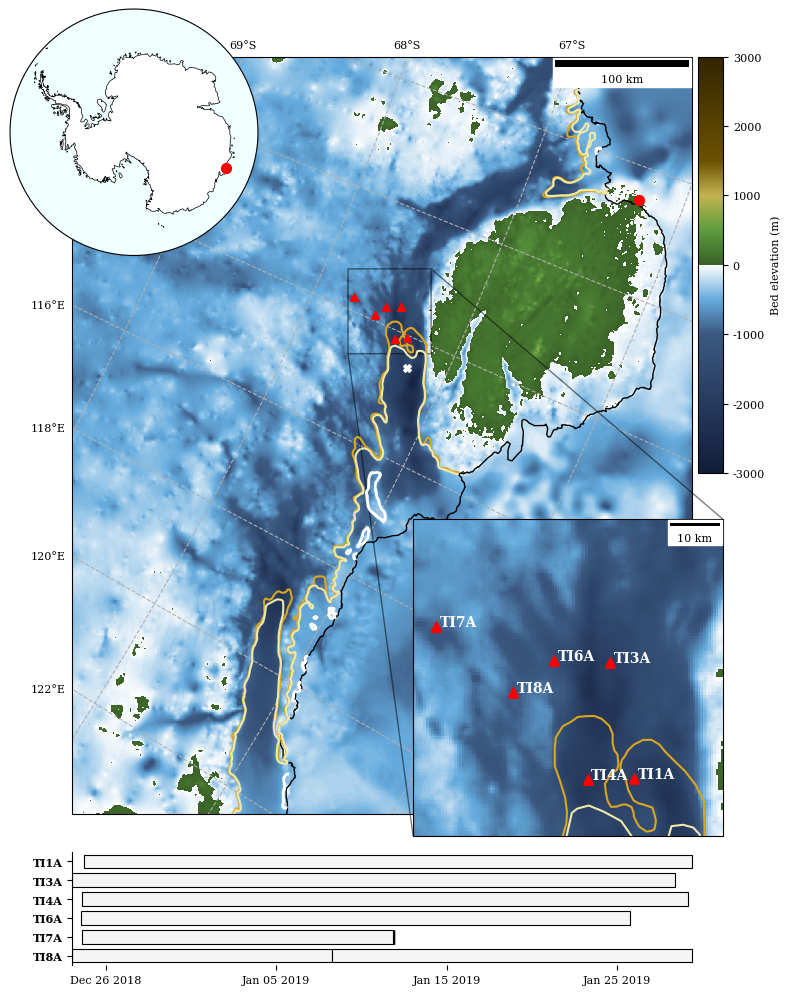

In [16]:
wgs84 = ccrs.PlateCarree()
stereo = ccrs.epsg(3031)

# --- Reproject grounding line records ---
up_ll = [reproject_geom(rec.geometry) for rec in up]
dn_ll = [reproject_geom(rec.geometry) for rec in dn]
isl_ll = [reproject_geom(rec.geometry) for rec in isl]

# --- Reproject coastline if needed ---
coast_ll = [reproject_geom(geom) for geom in coastline_data.geometries()]

# --- Figure ---
fig = plt.figure(figsize=(8, 10))
ax = fig.add_subplot(111, projection=ccrs.SouthPolarStereo())



ax.set_extent([110, 121, -68.4, -66], crs = wgs84) # Define map extent in axis via [minlon, maxlon, minlat, maxlat]

#ax_spare = fig.add_subplot(122, projection = ccrs.SouthPolarStereo()) # Uncomment this if you want to see how Obspy handles multiple subplots!

# Add BedMachine & MEaSUREs data to map & style (as before)
#bedmachine_data = nc.Dataset(bedmachine_file)
#pcm = ax.pcolormesh(bedmachine_data.variables['x'][::10], bedmachine_data.variables['y'][::10], bedmachine_data.variables['bed'][::10,::10],
                    #cmap = cmap_bedmachine(), transform = ccrs.epsg(3031), vmin = -3000, vmax = 3000) # N.B. Rerun custom colormaps block above

# Raster (stays in EPSG:3031)
pcm = ax.pcolormesh(x_crop, y_crop, bed_crop,cmap=cmap_bedmachine(),transform=stereo,vmin=-3000, vmax=3000,zorder=1)


# Grounding lines (now in lon/lat)
ax.add_geometries(up_ll, crs=wgs84, facecolor="none", edgecolor="goldenrod", linewidth=1.5, zorder=10)
ax.add_geometries(dn_ll, crs=wgs84, facecolor="none", edgecolor="palegoldenrod", linewidth=1.5, zorder=10)
ax.add_geometries(isl_ll, crs=wgs84, facecolor="none", edgecolor="white", linewidth=1.5, zorder=10)

# Coastline
ax.add_geometries(coast_ll, crs=wgs84, facecolor="none", edgecolor="black", linewidth=1, zorder=5)

# Stations (already lon/lat)
station_df.plot.scatter(ax=ax, x="Longitude", y="Latitude",transform=wgs84, c="red", marker="^", s=30, zorder=20)


#ax.gridlines(draw_labels = True, linestyle = '--')

gl = ax.gridlines(crs=wgs84, draw_labels = {'top':'y','left':'x'}, linestyle = '--',x_inline=False,y_inline=False,rotate_labels=False)


station_df.plot.scatter(ax = ax, x = 'Longitude', y = 'Latitude', transform = wgs84, c = 'red', marker = '^', s = 30,zorder=10)

ant_ax = ax.inset_axes(bounds = [-0.1, 0.7, 0.4, 0.4], transform = ax.transAxes, projection = map_proj)
ant_ax.set_extent([0,360,-90,-60],crs=wgs84)
ant_ax.coastlines(lw=0.5)
ant_ax.add_feature(ctp.feature.OCEAN,facecolor='azure')
#ant_ax.add_geometries(coastline_data.geometries(), ccrs.epsg(3031), facecolor='white', edgecolor = 'black',lw=0.3)

theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts*radius + center)
ant_ax.set_boundary(circle, transform = ant_ax.transAxes)

#ant_ax.scatter(centre[0],centre[1],s=30,marker='o',color='red',transform=wgs84,zorder=5)
ant_ax.scatter(casey_lon,casey_lat,s=50,marker='o',color='red',transform=wgs84,zorder=10)

scalebar = ScaleBar(0.001, "km", fixed_value=100)
ax.add_artist(scalebar)

inset_ax1 = ax.inset_axes(bounds = [1.01, 0.45, 0.04, 0.55], transform = ax.transAxes)
clb = fig.colorbar(pcm, cax = inset_ax1)
clb.set_label('Bed elevation (m)')
inset_ax1.set_yticks([-3000,-2000,-1000,0,1000,2000,3000],['-3000','-2000','-1000','0','1000','2000','3000'])

inset_ax2 = ax.inset_axes(bounds = [0.55, -0.07, 0.5, 0.5], transform = ax.transAxes, projection = map_proj)
inset_ax2.set_extent([113.2, 114.3, -67.7, -67.3], crs = wgs84)
ax.indicate_inset_zoom(inset_ax2, edgecolor = 'black') # indicate on main axes the inset axes
inset_ax2.pcolormesh(x_crop, y_crop, bed_crop,cmap=cmap_bedmachine(),transform=stereo,vmin=-3000, vmax=3000,zorder=1) # N.B. Rerun custom colormaps block above
#inset_ax2.add_geometries(groundingline_data2.geometries(), wgs84, facecolor = 'none', edgecolor = 'yellow', linewidth = 1)
#inset_ax2.add_geometries(groundingline_data.geometries(), ccrs.epsg(3031), facecolor = 'none', edgecolor = 'white', linewidth = 1,linestyle='--')

# Grounding lines (now in lon/lat)
inset_ax2.add_geometries(up_ll, crs=wgs84, facecolor="none", edgecolor="goldenrod", linewidth=1.5, zorder=10)
inset_ax2.add_geometries(dn_ll, crs=wgs84, facecolor="none", edgecolor="palegoldenrod", linewidth=1.5, zorder=10)
inset_ax2.add_geometries(isl_ll, crs=wgs84, facecolor="none", edgecolor="white", linewidth=1.5, zorder=10)

inset_ax2.add_geometries(coast_ll, crs=wgs84, facecolor="none", edgecolor="black", linewidth=1, zorder=5)


#inset_ax2.add_geometries(grounding_zone_data.geometries(), ccrs.epsg(3031), facecolor = 'none', edgecolor = 'yellow', linewidth = 1.2)


station_df.plot.scatter(ax = inset_ax2, x = 'Longitude', y = 'Latitude', transform = wgs84, c = 'red', marker = '^', s = 50,zorder=10)


for i, row in station_df.iterrows():
    station_ll = map_proj.transform_point(row['Longitude'],row['Latitude'],wgs84)
    #inset_ax2.annotate(fr"\textbf{{{row['Station']}}}",station_ll,c='white',zorder=15)
    inset_ax2.annotate(row['Station'],station_ll,c='white',zorder=15,weight='bold',fontsize=10,xytext=(0.25,0), textcoords='offset fontsize')

tide_xy = map_proj.transform_point(tide_lon,tide_lat,wgs84)
casey_xy = map_proj.transform_point(casey_lon,casey_lat,wgs84)

ax.scatter(tide_xy[0],tide_xy[1],color='white',marker='X',s=30,zorder=10)
ax.scatter(casey_xy[0],casey_xy[1],color='red',marker='o',s=50,zorder=10)


scalebar2 = ScaleBar(0.001, "km", fixed_value=10)
inset_ax2.add_artist(scalebar2)

avail = pd.read_csv('totten_stream_availability.csv')

avail_ax = ax.inset_axes(bounds = [0, -0.2, 1.05, 0.15], transform = ax.transAxes)

i = 0
labels = []
coords = []

rows = []

for i, row in station_df.iterrows():
   

    subset = avail[(avail['Station']==row['Station']) & (avail['Channel']=='CHZ')]
    
    starts = subset['Start'].to_numpy()
    ends = subset['End'].to_numpy()

    short_start = []
    short_end = []
    short_start.append(starts[0])

    for i, start in enumerate(starts[1:]):
        if start != ends[i]:
            short_start.append(start)
            short_end.append(ends[i])

    short_end.append(ends[-1])

    for i in range(len(short_start)):
        rows.append({'Station':row['Station'],'Start':short_start[i],'End':short_end[i]})

df = pd.DataFrame(data=rows)

for i, row in station_df.iterrows():
    subset = df[(df['Station']==row['Station'])]
    start = pd.to_datetime(subset['Start'])# + pd.Timedelta(hours=chunk.time_offset)
    end = pd.to_datetime(subset['End']) #+ pd.Timedelta(hours=chunk.time_offset)
    duration = end - start

    color='whitesmoke'
        
    avail_ax.barh(-i,duration,height=0.7,left=start,facecolor=color,edgecolor='black',lw=0.8)
    coords.append(-i)
    #labels.append(fr"\textbf{{{row['Station']}}}")
    labels.append(row['Station'])

avail_ax.set_yticks(coords)
avail_ax.set_yticklabels(labels,weight='bold')
avail_ax.spines['right'].set_visible(False)
#avail_ax.spines['left'].set_visible(False)
avail_ax.spines['top'].set_visible(False)
avail_ax.spines['bottom'].set_visible(False)

myFmt = DateFormatter("%b %d %Y",usetex=False)
avail_ax.xaxis.set_major_formatter(myFmt)
avail_ax.xaxis.set_major_locator(DayLocator(interval=10))

#_set_xaxis_obspy_dates(avail_ax)
avail_ax.set_ylim(-5.5,0.5)

plt.show();

fig.savefig(os.path.join(cloud_path,'A_GZ_Totten_Network.png'),bbox_inches='tight',dpi=400)

In [19]:
t1 = UTCDateTime(2018,12,24)
t2 = UTCDateTime(2019,1,30)

psd_window = 5
psd_overlap = 0.5

chunk = do.SeismicChunk(t1,t2)

path = '/Users/jmagyar/Documents/TottenData'
w_path = os.path.join(path,'waveforms')
s_path = os.path.join(path,'stations')
c_path = os.path.join(path,'catalogues')
p_path = os.path.join(path,'event_plots')
spec_path = os.path.join(path,'spectrograms')

cloud_path = '/Users/jmagyar/Library/Mobile Documents/com~apple~CloudDocs/Outputs/Icequakes'


inv_files = os.listdir(s_path)

inv = inventory.Inventory()

for file in inv_files:
    temp_path = os.path.join(s_path,file)
    inv += inventory.read_inventory(temp_path,level='response',format='STATIONXML')

inv = inv.select(station='TI?A',channel='CH?')

In [20]:
network_cat = do.EventCatalogue(t1,t2,os.path.join(c_path,'network'))

/Users/jmagyar/Documents/icequakecode/cryoquake/src/cryoquake/data_objects.py:655: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  event_cat = pd.concat(events,ignore_index=True)
/Users/jmagyar/Documents/icequakecode/cryoquake/src/cryoquake/data_objects.py:666: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  trace_cat = pd.concat(traces,ignore_index=True)


In [21]:
stations = ['TI1','TI3','TI4','TI6','TI7','TI8']
avail = pd.read_csv('totten_stream_availability.csv')
rows = []

for code in stations:
    subset = avail[(avail['Station']==code + 'A') & (avail['Channel']=='CHZ')]
    starts = subset['Start'].to_numpy()
    ends = subset['End'].to_numpy()

    short_start = []
    short_end = []
    short_start.append(starts[0])

    for i, start in enumerate(starts[1:]):
        if start != ends[i]:
            short_start.append(start)
            short_end.append(ends[i])

    short_end.append(ends[-1])

    for i in range(len(short_start)):
        rows.append({'Station':code,'Start':short_start[i],'End':short_end[i]})

df = pd.DataFrame(data=rows)

In [22]:
tides = np.load('totten_tides.npz')
dt = tides['dt']
tide = tides['tide']

tide = tide[dt <= (t2 - t1)]
dt = dt[dt <= (t2 - t1)]

analytic_signal = hilbert(tide)
amplitude_envelope = np.abs(analytic_signal)
instantaneous_phase = np.unwrap(np.angle(analytic_signal))
tidal_phase = (instantaneous_phase % (2*np.pi) - np.pi) * 180/np.pi

tidal_phase += 180
tidal_phase[tidal_phase > 180] -= 360

KeyError: 'time'

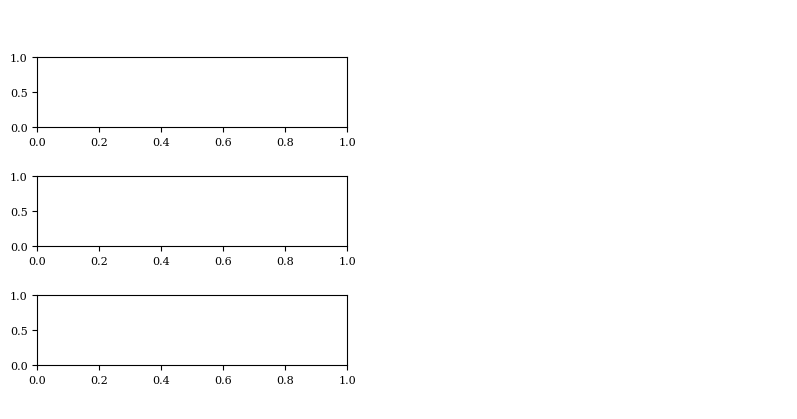

In [23]:

master_fig = plt.figure(figsize=(8,4))
dist_fig, att_fig = master_fig.subfigures(ncols=2)

dist_gs = dist_fig.add_gridspec(nrows=3,hspace=0.7)

det_ax = dist_fig.add_subplot(dist_gs[0])
diurnal_ax = dist_fig.add_subplot(dist_gs[1])
tide_ax = dist_fig.add_subplot(dist_gs[2])

fine_bins = np.array([time.matplotlib_date for time in np.mgrid[chunk.starttime:chunk.endtime+1:12*60*60]])
stalta_hist, _ = np.histogram(network_cat.attributes['time'],bins=fine_bins)


det_ax.bar(fine_bins[:-1],stalta_hist,width=np.diff(fine_bins),facecolor='whitesmoke',edgecolor='black',lw=0.5)

det_ax.spines['top'].set_visible(False)
det_ax.spines['left'].set_visible(False)
det_ax.spines['right'].set_visible(False)
det_ax.set_yticks([])

myFmt = DateFormatter("%b %d %Y",usetex=False)
det_ax.xaxis.set_major_formatter(myFmt)
det_ax.xaxis.set_major_locator(DayLocator(interval=15))


day_bins = np.array([time.matplotlib_date for time in np.mgrid[UTCDateTime(2018,1,1):UTCDateTime(2018,1,2)+1:30*60]])
temp_hist, _ = np.histogram(network_cat.attributes['diurnal'],bins=day_bins)

diurnal_ax.bar(day_bins[:-1],temp_hist,width=np.diff(day_bins),align='edge',facecolor='whitesmoke',edgecolor='black',lw=0.5)


myFmt = DateFormatter("%H:%M")
diurnal_ax.xaxis.set_major_formatter(myFmt)
diurnal_ax.xaxis.set_major_locator(HourLocator(interval=4))
diurnal_ax.spines['top'].set_visible(False)
diurnal_ax.spines['left'].set_visible(False)
diurnal_ax.spines['right'].set_visible(False)
diurnal_ax.set_yticks([])
diurnal_ax.set_xlabel('Time of Day')

tide_bins = np.linspace(-180,180,48)
temp_hist, _ = np.histogram(network_cat.attributes['phase'],bins=tide_bins)

tide_ax.bar(tide_bins[:-1],temp_hist,width=np.diff(tide_bins),align='edge',facecolor='whitesmoke',edgecolor='black',lw=0.5)

tide_ax.spines['top'].set_visible(False)
tide_ax.spines['left'].set_visible(False)
tide_ax.spines['right'].set_visible(False)
tide_ax.set_yticks([])
tide_ax.set_xlabel('Tidal Phase')
tide_ax.set_xticks([-180,-90,0,90,180]);


#ATTRIBUTES SUBFIGURE
grid_spec = att_fig.add_gridspec(ncols=3,nrows=3,width_ratios=[1,1,1],height_ratios=[1,1,1],hspace=0.1,wspace=0.1)

amp_hist = att_fig.add_subplot(grid_spec[0,0])
freq_hist = att_fig.add_subplot(grid_spec[1,1])
dur_hist = att_fig.add_subplot(grid_spec[2,2])

amp_hist.set_xscale('log')
freq_hist.set_xscale('log')
dur_hist.set_xscale('log')

amp_freq = att_fig.add_subplot(grid_spec[1,0],sharex=amp_hist)
amp_dur = att_fig.add_subplot(grid_spec[2,0],sharex=amp_hist)
freq_dur = att_fig.add_subplot(grid_spec[2,1],sharex=freq_hist)

amp_freq.set_xscale('log')
amp_freq.set_yscale('log')
amp_dur.set_xscale('log')
amp_dur.set_yscale('log')
freq_dur.set_yscale('log')
freq_dur.set_xscale('log')


amps = network_attributes['amplitude'].to_numpy()
freqs = network_attributes['mean_freq'].to_numpy()
durs = network_attributes['duration'].to_numpy()

amp_count, _ = np.histogram(amps,bins=amp_bins)
freq_count, _ = np.histogram(freqs,bins=freq_bins)
dur_count, _ = np.histogram(durs,bins=dur_bins)

amp_freq_count, _, _ = np.histogram2d(amps,freqs,bins=(amp_bins,freq_bins))
amp_dur_count, _, _ = np.histogram2d(amps,durs,bins=(amp_bins,dur_bins))
freq_dur_count, _, _ = np.histogram2d(freqs,durs,bins=(freq_bins,dur_bins))

freq_hist.bar(freq_bins[:-1],height=freq_count,width=np.diff(freq_bins),align='edge',facecolor='whitesmoke',edgecolor='black',lw=0.5)
freq_hist.set_yticks([])

amp_hist.bar(amp_bins[:-1],height=amp_count,width=np.diff(amp_bins),align='edge',facecolor='whitesmoke',edgecolor='black',lw=0.5)
amp_hist.set_yticks([])

dur_hist.bar(dur_bins[:-1],height=dur_count,width=np.diff(dur_bins),align='edge',facecolor='whitesmoke',edgecolor='black',lw=0.5)
dur_hist.set_yticks([])

amp_dur.set_ylim(dur_hist.get_xlim())
freq_dur.set_ylim(dur_hist.get_xlim())


amp_freq.pcolormesh(amp_bins,freq_bins,amp_freq_count.T,cmap='binary')
amp_dur.pcolormesh(amp_bins,dur_bins,amp_dur_count.T,cmap='binary')
freq_dur.pcolormesh(freq_bins,dur_bins,freq_dur_count.T,cmap='binary')

amp_ylim = amp_hist.get_ylim()
amp_hist.set_ylim(amp_ylim)

freq_ylim = freq_hist.get_ylim()
freq_hist.set_ylim(freq_ylim)

dur_ylim = dur_hist.get_ylim()
dur_hist.set_ylim(dur_ylim)

amp_freq.set_xlim(amp_bins[0],amp_bins[-1])
amp_freq.set_ylim(freq_bins[0],freq_bins[-1])

amp_dur.set_xlim(amp_bins[0],amp_bins[-1])
amp_dur.set_ylim(dur_bins[0],dur_bins[-1])

freq_dur.set_xlim(freq_bins[0],freq_bins[-1])
freq_dur.set_ylim(dur_bins[0],dur_bins[-1])

plt.setp(freq_hist.get_xticklabels(), visible=False)
plt.setp(amp_hist.get_xticklabels(), visible=False)
plt.setp(amp_freq.get_xticklabels(), visible=False)
plt.setp(freq_dur.get_yticklabels(), visible=False)

amp_freq.set_ylabel('Frequency (Hz)')
amp_dur.set_ylabel('Duration (s)')
amp_dur.set_xlabel('Amplitude (count)')
freq_dur.set_xlabel('Frequency (Hz)')
dur_hist.set_xlabel('Duration (s)')

master_fig.savefig(os.path.join(cloud_path,'FigS1_network_catalogue.pdf'),bbox_inches='tight')

In [ ]:
clusters_file = np.load(os.path.join(c_path,'network','clusters_N.npz'))
clusters = clusters_file['clusters']

cc_file = np.load(os.path.join(c_path,'network','cc_matrix_N.npz'))
cc_mat = cc_file['cc_mat']

unique = pd.value_counts(clusters)
clust_ind = unique[unique>3] #if 3 or more events in cluster, get template 

templates = {}
template_loc = {}

for i, clust_N in enumerate(clust_ind):
    clust_id = clust_ind.index[i] #numerical label of cluster

    cc_ind = np.where(clusters==clust_id)[0] #indices in the cc matrix belonging to this cluster
    temp = cc_mat[cc_ind,:]
    clust_cc = temp[:,cc_ind]

    clust_events = network_cat.events.index[cc_ind]

    central_ind = np.argmax(np.mean(clust_cc,axis=1))
    central_id = clust_events[central_ind]

    templates[str(clust_id)] = central_id
    template_loc[str(clust_id)] = network_cat.events.index.get_loc(central_id)

In [ ]:
ind = np.argsort(clusters)

temp = cc_mat[ind,:]
cc_sort = temp[:,ind]

sort_temps = {}
for temp_id, temp_loc in template_loc.items():
    sort_temps[temp_id] = np.argwhere(ind==temp_loc)[0][0]

event_pos = {}
for clust_id, event_id in templates.items():
    event_pos[event_id] = sort_temps[clust_id]


#dendrograms of the chosen template events, relation between clusters
ind = np.array([i for i in event_pos.values()]) #will want to sort this A-J and label these on the axes
temp = cc_sort[ind,:]
cc_temp = temp[:,ind]

In [ ]:
from scipy.cluster import hierarchy
from scipy.spatial import distance

dissimilarity = 1-cc_temp
dissimilarity = distance.squareform(dissimilarity)
threshold = 0.2

linkage = hierarchy.linkage(dissimilarity, method="average",optimal_ordering=True)
clusters = hierarchy.fcluster(linkage, threshold, criterion="distance")

In [ ]:

master_fig = plt.figure(figsize=(8,6))

xcorr_fig, dendro_fig = master_fig.subfigures(nrows=2,height_ratios=(2,1.5),hspace=0)

gs = xcorr_fig.add_gridspec(nrows=len(template_loc),ncols=3,width_ratios=[0.05,1,1],hspace=0,wspace=0.05)

cb_ax = xcorr_fig.add_subplot(gs[:,0])
chron_ax = xcorr_fig.add_subplot(gs[:,1])
sort_ax = xcorr_fig.add_subplot(gs[:,2])

cc_plot = chron_ax.imshow(cc_mat,cmap='magma',vmin=0,vmax=1)
chron_ax.set_xticks([])
chron_ax.set_yticks([])

cc_plot = sort_ax.imshow(cc_sort,cmap='magma',vmin=0,vmax=1)
sort_ax.set_xticks([])
sort_ax.set_yticks([])

plt.colorbar(cc_plot,cax=cb_ax,label='Cross Correlation')
cb_ax.yaxis.set_ticks_position('left')
cb_ax.yaxis.set_label_position('left')
cb_ax.set_ylim(0,1)

i = 0
for clust_id, loc in template_loc.items():
    chron_ax.plot(loc,loc,marker='X',color='cyan')
    if i % 2 == 0:
        va = 'top'
    else:
        va = 'bottom'
    i += 1

for event_id, loc in event_pos.items():
    sort_ax.plot(loc,loc,marker='X',color='cyan')


dendro_gs = dendro_fig.add_gridspec(ncols=3,width_ratios = [1,3,0.4],wspace=0.1)
dend_ax = dendro_fig.add_subplot(dendro_gs[0])
waveform_ax = dendro_fig.add_subplot(dendro_gs[1])

labels = ['A','B','C','D','E','F','G','H','I','J']
temp_labels = {num:labels[i] for i,num in enumerate(sort_temps.keys())}
cluster_nums = [key for key in templates.keys()]


dend_ax.spines['top'].set_visible(False)
#dend_ax.spines['bottom'].set_visible(False)
dend_ax.spines['left'].set_visible(False)
dend_ax.spines['right'].set_visible(False)



waveform_ax.spines['top'].set_visible(False)
#waveform_ax.spines['bottom'].set_visible(False)
waveform_ax.spines['left'].set_visible(False)
waveform_ax.spines['right'].set_visible(False)

hierarchy.set_link_color_palette(['darkgreen','darkred','slategrey','peru','deeppink','olive'])

#dend_ax.vlines(threshold,ymin=0,ymax=10*len(event_list),color='grey',ls='--',lw=0.8)

dendrogram = hierarchy.dendrogram(linkage,color_threshold=0,orientation='left',ax=dend_ax,labels=cluster_nums,no_labels=True,above_threshold_color='black')

dend_ax.set_xlim(1,0)
dend_ax.set_xlabel('Dissimilarity')

old_index = None
station_names = []
for i, cluster_num in enumerate(dendrogram['ivl']):
    template_id = templates[cluster_num]
    offset = 5 + i * 10

    temp_event = network_cat.select_event(template_id)
    temp_event.attach_waveforms(inv.select(station='TI3A',channel='CHZ'),w_path,buffer=10,length=25)
    temp_event.filter('bandpass',freqmin=1,freqmax=100)  

    stream = temp_event.get_data_window()
    tr = stream.select(station='TI3A',channel='CHZ')[0]

    waveform_ax.plot(tr.times(),tr.data/tr.data.max()*5 + offset,lw=0.8,color='black')
    waveform_ax.set_xlim(0,30)

sorted_y_labels = [temp_labels[key] for key in dendrogram['ivl']]

waveform_ax.set_ylim((0,clusters.size*10))
waveform_ax.set_yticks(np.arange(0,clusters.size*10,10)+5)
#waveform_ax.set_yticklabels(station_names)
waveform_ax.set_yticklabels(sorted_y_labels,weight='bold')
waveform_ax.yaxis.set_ticks_position('right')

waveform_ax.set_xticks([0,30])
waveform_ax.set_xticklabels(['',''])
waveform_ax.tick_params(direction='inout')
waveform_ax.set_xlabel('30 seconds')

master_fig.savefig(os.path.join(cloud_path,'FigS2_template_selection.pdf'),bbox_inches='tight')

In [ ]:
temp_cat = do.EventCatalogue(t1,t2,os.path.join(c_path,'network','filtered'),templates=True)
groups = temp_cat.group_split()
print('Template Matched Events:',temp_cat.N)

In [ ]:
for event_id, row in temp_cat.attributes.iterrows():
    time = UTCDateTime(temp_cat.events.at[event_id,'ref_time'])
    temp_cat.attributes.at[event_id,'time'] = time.matplotlib_date
    temp_cat.attributes.at[event_id,'diurnal'] = UTCDateTime(2018,1,1,time.hour,time.minute,time.second).matplotlib_date
    delta_t = time - t1
    temp_cat.attributes.at[event_id,'phase'] = np.interp(delta_t,dt,tidal_phase)
    temp_cat.attributes.at[event_id,'height'] = np.interp(delta_t,dt,tide)

In [ ]:
stacked_streams = {}
for cluster_num in groups.keys():
    stream = read(os.path.join(path,'stacked_waveforms','filtered_stacked_waveforms_cluster_'+str(cluster_num) + '.mseed'))
    #stream = stream.select(station='TI?A')
    #stream = stream.filter("bandpass",freqmin=1,freqmax=10)
    #for tr in stream:
    #    tr.stats.starttime = UTCDateTime(2019,1,10)
    #    tr.remove_response(inv,output='DISP')

    stacked_streams[cluster_num] = stream

In [ ]:
ss_temps = dict(sort_temps)
ss_temps.pop('116')
ss_temps.pop('117')

In [ ]:
N_clust = len(ss_temps)
labels = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O']
temp_labels = {num:labels[i] for i,num in enumerate(ss_temps.keys())}

fig = plt.figure(figsize=(8,5))
gs = fig.add_gridspec(nrows=3*(N_clust+3),ncols=2,wspace=0.05,hspace=0.0)

all_hist = []
all_tr = []

i = 0
for clust_num, pos in ss_temps.items():

    hist_ax = fig.add_subplot(gs[3*i:3*i+2,0])
    tr_ax = fig.add_subplot(gs[3*i+1:3*i+3,1])

    all_hist.append(hist_ax)
    all_tr.append(tr_ax)

    group_cat = groups[int(clust_num)]
    for event_id, row in group_cat.attributes.iterrows():
        time = UTCDateTime(group_cat.events.at[event_id,'ref_time'])
        group_cat.attributes.at[event_id,'time'] = time.matplotlib_date
        group_cat.attributes.at[event_id,'diurnal'] = UTCDateTime(2018,1,1,time.hour,time.minute,time.second).matplotlib_date
        delta_t = time - t1
        group_cat.attributes.at[event_id,'phase'] = np.interp(delta_t,dt,tidal_phase)
        group_cat.attributes.at[event_id,'height'] = np.interp(delta_t,dt,tide)

    fine_bins = np.array([time.matplotlib_date for time in np.mgrid[chunk.starttime:chunk.endtime+1:24*60*60]])
    stalta_hist, _ = np.histogram(group_cat.attributes['time'],bins=fine_bins)

    hist_ax.bar(fine_bins[:-1],stalta_hist,width=np.diff(fine_bins),color='black')
    hist_ax.spines['top'].set_visible(False)
    #hist_ax.spines['left'].set_visible(False)
    hist_ax.spines['right'].set_visible(False)

    myFmt = DateFormatter("%d %b")
    hist_ax.xaxis.set_major_formatter(myFmt)
    hist_ax.xaxis.set_major_locator(DayLocator(interval=7))
    #if i != N_clust-1:
    plt.setp(hist_ax.get_xticklabels(), visible=False)

    if i == 4:
        hist_ax.set_ylabel('Daily Event Count')

    stream = stacked_streams[int(clust_num)]

    template_id = templates[str(clust_num)]

    temp_event = network_cat.select_event(template_id)
    temp_event.attach_waveforms(inv.select(station='TI3A',channel='CHZ'),w_path,buffer=10,length=25)
    
    temp_event.filter('bandpass',freqmin=1,freqmax=100)  

    t = stream.select(station='TI3A',component='Z')[0].times()

    tr_ax.plot(t,temp_event.get_data_window()[0].data,lw=1,color='red')
    tr_ax.plot(t,stream.select(station='TI3A',component='Z')[0].data,lw=0.7,c='k')    
    tr_ax.set_xlim(0,30)
    

    if i != N_clust-1:
        tr_ax.set_axis_off()



    else:
        tr_ax.spines['top'].set_visible(False)
        tr_ax.spines['left'].set_visible(False)
        tr_ax.spines['right'].set_visible(False)

        tr_ax.set_xticks([0,30])
        tr_ax.set_yticks([])
        tr_ax.set_xticklabels(['',''])
        tr_ax.tick_params(direction='inout')
        tr_ax.set_xlabel('30 seconds')

    N_group = groups[int(clust_num)].N

    tr_ax.annotate('N = ' + str(N_group),(1,1.25),xycoords='axes fraction',ha='right',va='top')
    hist_ax.annotate(temp_labels[clust_num],(0.01,1),xycoords='axes fraction',ha='left',va='top',weight='bold')
    i += 1

max_lim_hist = np.max(np.array([all_hist[i].get_ylim()[1] for i in range(N_clust)]))
max_lim_tr = np.max(np.array([np.max(np.abs(all_tr[i].get_ylim())) for i in range(N_clust)]))

for i in range(N_clust):
    all_hist[i].set_ylim(0,max_lim_hist)
    all_hist[i].set_yticks([50])

    max_y = np.max(np.abs(all_tr[i].get_ylim()))
    #all_tr[i].set_ylim(-max_lim_tr,max_lim_tr)
    all_tr[i].set_ylim(-max_y,max_y)

total_ax = fig.add_subplot(gs[3*(N_clust):3*(N_clust+1),0])

stalta_hist, _ = np.histogram(temp_cat.attributes['time'],bins=fine_bins)

total_ax.bar(fine_bins[:-1],stalta_hist,width=np.diff(fine_bins),color='black')
total_ax.spines['top'].set_visible(False)
#hist_ax.spines['left'].set_visible(False)
total_ax.spines['right'].set_visible(False)

myFmt = DateFormatter("%d %b")
total_ax.xaxis.set_major_formatter(myFmt)
total_ax.xaxis.set_major_locator(DayLocator(interval=7))
#if i != N_clust-1:
plt.setp(total_ax.get_xticklabels(), visible=False)

total_ax.set_yticks([100])
total_ax.annotate('All',(0.01,1),xycoords='axes fraction',ha='left',va='top',weight='bold')



tide_ax = fig.add_subplot(gs[3*(N_clust+1)+1:,0])
tide_times = np.full(dt.size,fill_value=t1) + dt
tide_times_mt = np.array([time.matplotlib_date for time in tide_times])
tide_ax.plot(tide_times_mt,tide,lw=0.75,color='k')
tide_ax.set_ylim(-1.3,1.3)
tide_ax.set_ylabel('Tide Height (m)')
tide_ax.set_yticks([-1,0,1])
tide_ax.spines['top'].set_visible(False)
#tide_ax.spines['bottom'].set_visible(False)
tide_ax.spines['right'].set_visible(False)

myFmt = DateFormatter("%d %b")
tide_ax.xaxis.set_major_formatter(myFmt)
tide_ax.xaxis.set_major_locator(DayLocator(interval=7))


fig.savefig(os.path.join(p_path,'Fig2_template_catalogues.pdf'),bbox_inches='tight')
fig.savefig(os.path.join(p_path,'Fig2_template_catalogues.png'),dpi=400,bbox_inches='tight')